# 3W Dataset — Sensor Availability and Cleaning-Impact Overview

**Author:** Gabriel Rozo

**Description:** An exploratory overview quantifying how often each sensor is actually usable across the 3W Dataset (before and after signal cleaning) broken down by undesirable-event class. The goal is to map the real availability of the data, a property that directly affects how detection models must be designed.


## 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import CleanSignalsConfig

# Path to the dataset folder, relative to this notebook
dataset_path = "../../../dataset"

# Load the full 3W dataset
ds = ParquetDatasetConfig(path=dataset_path).build()
print(f"Total events in the dataset: {len(ds)}")

2026-07-12 20:32:13,283 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ..\..\..\dataset
2026-07-12 20:32:13,284 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-07-12 20:32:13,285 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Total events in the dataset: 2228


## 2. The Problem, Up Close

Real wells don't record every sensor, and some readings are frozen or invalid. The toolkit's `CleanSignals` step uses IQR-based thresholds to drop unreliable columns automatically. Let's see how many survive for a single event.

In [2]:
# Fit the cleaner on the dataset and apply it (lazy: cleans each event on access)
cleaner = TransformConfig(pre_processing=CleanSignalsConfig()).build()
cleaner.fit(ds)
ds_clean = cleaner.transform(ds)

# Compare one event before and after cleaning
cols_before = ds[0].signal.columns.tolist()
cols_after = ds_clean[0].signal.columns.tolist()
dropped = [c for c in cols_before if c not in cols_after]

print(f"Before cleaning: {len(cols_before)} columns")
print(f"After cleaning:  {len(cols_after)} columns")
print(f"Dropped ({len(dropped)}): {dropped}")

Before cleaning: 28 columns
After cleaning:  15 columns
Dropped (13): ['ABER-CKGL', 'ABER-CKP', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-SDV-P', 'PT-P', 'QBS', 'QGL', 'T-MON-CKP', 'T-PDG']


## 3. Measuring Raw Sensor Availability

Automatic cleaning can give run-dependent results, so instead we measure a raw, reproducible quantity: for each event, the fraction of valid (non-missing) readings of each sensor, averaged per event class. A value of 1.0 means the sensor is fully recorded; 0.0 means it is never available.

In [3]:
import numpy as np

# The 18 measurement sensors (pressures, temperatures, flows, valve openings)
sensor_cols = [
    "ABER-CKGL", "ABER-CKP",
    "P-ANULAR", "P-JUS-BS", "P-JUS-CKGL", "P-JUS-CKP", "P-MON-CKGL",
    "P-MON-CKP", "P-MON-SDV-P", "P-PDG", "PT-P", "P-TPT",
    "QBS", "QGL",
    "T-JUS-CKP", "T-MON-CKP", "T-PDG", "T-TPT",
]

rng = np.random.default_rng(42)   # fixed seed -> fully reproducible
SAMPLE_PER_CLASS = 20

rows = {}
for k in range(10):
    ds_k = ParquetDatasetConfig(path=dataset_path, target_class=[k]).build()
    n = len(ds_k)
    if n == 0:
        continue
    idx = rng.choice(n, size=min(SAMPLE_PER_CLASS, n), replace=False)
    fracs = {c: [] for c in sensor_cols}
    for i in idx:
        sig = ds_k[int(i)].signal
        for c in sensor_cols:
            fracs[c].append(sig[c].notna().mean() if c in sig.columns else 0.0)
    rows[k] = {c: float(np.mean(v)) for c, v in fracs.items()}

# Availability table: rows = class, cols = sensor, value = avg fraction present
avail = pd.DataFrame(rows).T
avail.index.name = "class"
print(avail.round(2))

2026-07-12 20:45:07,829 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ..\..\..\dataset
2026-07-12 20:45:07,830 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-07-12 20:45:07,831 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-07-12 20:45:08,075 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ..\..\..\dataset
2026-07-12 20:45:08,076 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-07-12 20:45:08,077 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-07-12 20:45:08,477 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ..\..\..\dataset
2026-07-12 20:45:08,478 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-07-12 20:45:08,479 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-07-12 20:45:08,735 | INFO | ThreeWToolkit.da

       ABER-CKGL  ABER-CKP  P-ANULAR  P-JUS-BS  P-JUS-CKGL  P-JUS-CKP  \
class                                                                   
0           0.10      0.10      0.90       0.0        0.70       0.00   
1           0.00      0.00      0.05       0.0        0.00       0.00   
2           0.00      0.10      0.65       0.0        0.00       0.00   
3           0.20      0.20      0.25       0.0        0.25       0.00   
4           0.30      0.30      0.75       0.0        0.50       0.00   
5           0.05      0.05      0.10       0.0        0.10       0.90   
6           0.00      0.00      0.00       0.0        0.00       1.00   
7           0.25      0.25      0.70       0.0        0.85       0.00   
8           0.00      0.20      0.10       0.0        0.20       0.15   
9           0.15      0.15      0.10       0.0        1.00       0.00   

       P-MON-CKGL  P-MON-CKP  P-MON-SDV-P  P-PDG  PT-P  P-TPT  QBS   QGL  \
class                                          

## 4. The Availability Map

The heatmap below turns the table into a picture: green means a sensor is usually present, red means it is usually missing. Two things stand out — some sensors are almost never recorded, and availability changes from one event class to another.

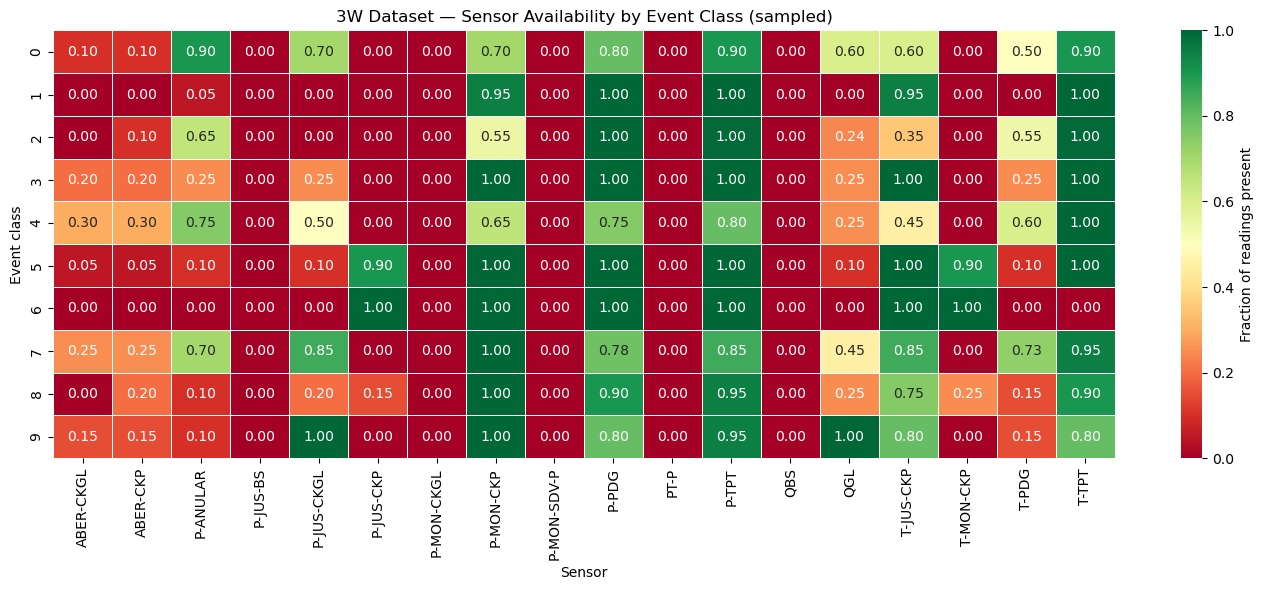

In [4]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(
    avail,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Fraction of readings present"},
)
plt.title("3W Dataset — Sensor Availability by Event Class (sampled)")
plt.xlabel("Sensor")
plt.ylabel("Event class")
plt.tight_layout()
plt.show()

## 5. Findings and Takeaways

This overview measured the raw availability (fraction of non-missing readings) of 18 process sensors across the ten event classes of the 3W Dataset. Three patterns emerge:

1. **Several sensors are almost never recorded.** `P-JUS-BS`, `P-MON-CKGL`, `P-MON-SDV-P`, `PT-P` and `QBS` are absent across all classes in the sample. Models should not rely on them.

2. **A small, reliable backbone exists.** `P-PDG`, `P-TPT` and `P-MON-CKP` are present in most events of most classes, making them the most dependable features.

3. **Availability is class-dependent.** Some sensors appear almost exclusively in specific classes — for example, `P-JUS-CKP` and `T-MON-CKP` are essentially only available for classes 5 and 6. A detection model therefore cannot assume a fixed set of input features across events, which motivates approaches that are robust to missing sensors.

**A note on reproducibility:** the toolkit's automatic `CleanSignals` step produced run-dependent column selections for the same event, so this analysis instead measures the raw, deterministic missing-data fraction, using a fixed random seed for sampling.

*Results above use a fixed sample of 20 events per class for speed; the same analysis can be run over the full dataset before submission.*